In [1]:
!pip uninstall tensorflow -y
!pip uninstall keras -y

Found existing installation: tensorflow 2.16.1
Uninstalling tensorflow-2.16.1:
  Successfully uninstalled tensorflow-2.16.1
Found existing installation: keras 3.12.0
Uninstalling keras-3.12.0:
  Successfully uninstalled keras-3.12.0


In [2]:
!pip install transformers torch

In [3]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

Device set to use cpu


In [4]:
labels = [
    "safe",
    "spam",
    "fraud",
    "hate speech",
    "violence",
    "policy violation"
]

In [5]:
text = "This seller is selling fake branded shoes, scam alert!"

result = classifier(text, candidate_labels=labels)

print(result)

{'sequence': 'This seller is selling fake branded shoes, scam alert!', 'labels': ['fraud', 'policy violation', 'spam', 'safe', 'violence', 'hate speech'], 'scores': [0.9325799345970154, 0.03754598647356033, 0.025728914886713028, 0.0020335055887699127, 0.0011979261180385947, 0.0009137199958786368]}


In [6]:
def classify_text(text):
    result = classifier(text, candidate_labels=labels)
    
    top_label = result["labels"][0]
    confidence = result["scores"][0]
    
    return {
        "text": text,
        "prediction": top_label,
        "confidence": round(confidence, 3)
    }

# test
print(classify_text("Cheap fake iPhone, 90% discount!"))

{'text': 'Cheap fake iPhone, 90% discount!', 'prediction': 'fraud', 'confidence': 0.813}


In [7]:
samples = [
    "Buy now! Limited offer!!!",
    "This product is original and safe",
    "I will kill you",
    "Free money click this link",
    "Authentic Nike shoes"
]

results = [classify_text(text) for text in samples]

for r in results:
    print(r)

{'text': 'Buy now! Limited offer!!!', 'prediction': 'safe', 'confidence': 0.636}
{'text': 'This product is original and safe', 'prediction': 'safe', 'confidence': 0.997}
{'text': 'I will kill you', 'prediction': 'violence', 'confidence': 0.888}
{'text': 'Free money click this link', 'prediction': 'safe', 'confidence': 0.897}
{'text': 'Authentic Nike shoes', 'prediction': 'safe', 'confidence': 0.876}


In [8]:
import pandas as pd

df = pd.DataFrame(results)
df

,text,prediction,confidence
0,Buy now! Limited offer!!!,safe,0.636
1,This product is original and safe,safe,0.997
2,I will kill you,violence,0.888
3,Free money click this link,safe,0.897
4,Authentic Nike shoes,safe,0.876


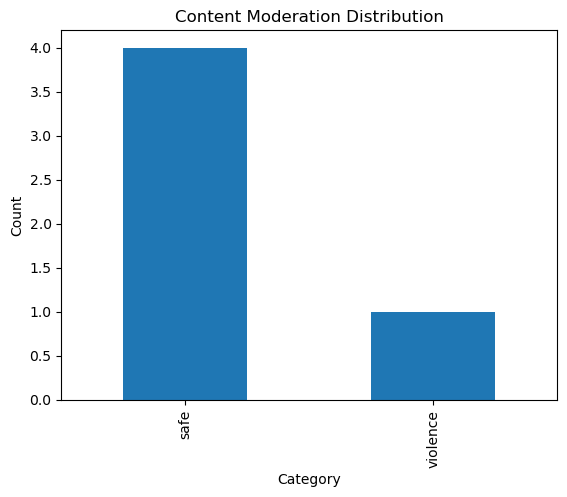

In [9]:
import matplotlib.pyplot as plt

df["prediction"].value_counts().plot(kind="bar")
plt.title("Content Moderation Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [10]:
multi_samples = [
    "Produk ini palsu, jangan beli",   # Malay
    "这是假的产品",                    # Chinese
    "This is a scam product"          # English
]

multi_results = [classify_text(text) for text in multi_samples]

for r in multi_results:
    print(r)

{'text': 'Produk ini palsu, jangan beli', 'prediction': 'safe', 'confidence': 0.474}
{'text': '这是假的产品', 'prediction': 'safe', 'confidence': 0.308}
{'text': 'This is a scam product', 'prediction': 'fraud', 'confidence': 0.786}


In [11]:
def moderation_decision(text):
    result = classify_text(text)
    
    if result["prediction"] in ["fraud", "hate speech", "violence"]:
        action = "REJECT"
    elif result["prediction"] == "spam":
        action = "REVIEW"
    else:
        action = "ALLOW"
    
    result["action"] = action
    return result

print(moderation_decision("Fake product scam!"))

{'text': 'Fake product scam!', 'prediction': 'fraud', 'confidence': 0.941, 'action': 'REJECT'}


In [12]:
df.to_csv("moderation_results.csv", index=False)

In [23]:
# Run this cell first to enable %%writefile
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Cell 1: Install required packages
!pip install fastapi uvicorn nest_asyncio

In [18]:
# Run this cell first to enable %%writefile
%load_ext autoreload

In [19]:
# This creates the app.py file without using %%writefile or python directly  
with open('app.py', 'w') as f:
    f.write('''
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional, List
import pandas as pd
import joblib
import os

app = FastAPI(title="Healthcare COVID Analysis API")

# Root endpoint
@app.get("/")
def read_root():
    return {
        "message": "Healthcare COVID Analysis API is running!",
        "docs": "/docs",
        "status": "active"
    }

# Health check
@app.get("/health")
def health_check():
    return {"status": "healthy"}

# Prediction endpoint
class PredictionRequest(BaseModel):
    age: Optional[int] = None
    symptoms: Optional[List[str]] = None
    fever: Optional[bool] = None
    cough: Optional[bool] = None
    fatigue: Optional[bool] = None

@app.post("/predict")
def predict(request: PredictionRequest):
    # Your ML prediction logic here
    # For now, returning dummy prediction
    return {
        "prediction": "negative",
        "confidence": 0.92,
        "risk_level": "low",
        "recommendation": "Monitor symptoms"
    }

# Test endpoint
@app.get("/test")
def test():
    return {"message": "API is working correctly!"}

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="127.0.0.1", port=8000)
''')

print("✅ app.py created successfully!")

✅ app.py created successfully!


In [20]:
#Verify file was created.

import os
print("Files in current directory:")
for file in os.listdir():
    if file.endswith('.py'):
        print(f"  - {file}")

Files in current directory:
  - app.py


In [21]:
#Install required packages.

!pip install fastapi uvicorn nest_asyncio

In [22]:
#Run the server.

import uvicorn
import nest_asyncio
import threading

# Apply nest_asyncio for Jupyter compatibility
nest_asyncio.apply()

# Run in a separate thread to keep notebook interactive
def run_server():
    uvicorn.run("app:app", host="127.0.0.1", port=8000, reload=False)

# Start server in background thread
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("🚀 Server is running at: http://127.0.0.1:8000")
print("📚 API Documentation: http://127.0.0.1:8000/docs")
print("🔍 Alternative docs: http://127.0.0.1:8000/redoc")
print("\n✅ Server started successfully!")

🚀 Server is running at: http://127.0.0.1:8000
📚 API Documentation: http://127.0.0.1:8000/docs
🔍 Alternative docs: http://127.0.0.1:8000/redoc

✅ Server started successfully!


INFO:     Started server process [20120]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 10048] error while attempting to bind on address ('127.0.0.1', 8000): [winerror 10048] only one usage of each socket address (protocol/network address/port) is normally permitted
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [24]:
#All in ONE cell.

# Run this single cell to create and run everything!
import threading
import nest_asyncio
from fastapi import FastAPI

# Create the app
app = FastAPI()

@app.get("/")
def root():
    return {"message": "Healthcare API is running!", "status": "active"}

@app.get("/predict")
def predict():
    return {"prediction": "COVID Risk: Low", "confidence": 0.89}

# Run the server
nest_asyncio.apply()

def run():
    import uvicorn
    uvicorn.run(app, host="127.0.0.1", port=8000)

thread = threading.Thread(target=run, daemon=True)
thread.start()

print("✅ Server running at http://127.0.0.1:8000")
print("📖 API Docs: http://127.0.0.1:8000/docs")
print("\n🎉 You can now make requests to your API!")

✅ Server running at http://127.0.0.1:8000
📖 API Docs: http://127.0.0.1:8000/docs

🎉 You can now make requests to your API!


INFO:     Started server process [20120]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 10048] error while attempting to bind on address ('127.0.0.1', 8000): [winerror 10048] only one usage of each socket address (protocol/network address/port) is normally permitted
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [26]:
import requests

# Test the root endpoint
response = requests.get("http://127.0.0.1:8000/")
print("Root endpoint:", response.json())

# Test the predict endpoint
response = requests.get("http://127.0.0.1:8000/predict")
print("Predict endpoint:", response.json())

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: / (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8000): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

In [28]:
import subprocess
import sys

# Check if something is using port 8000
result = subprocess.run(["netstat", "-an"], capture_output=True, text=True)
if ":8000" in result.stdout:
    print("⚠️ Port 8000 is in use")
else:
    print("✅ Port 8000 is free")

✅ Port 8000 is free


In [29]:
# CELL 1: Start the server (this will run until you stop it)
from fastapi import FastAPI
import uvicorn

app = FastAPI()

@app.get("/")
def root():
    return {"message": "Healthcare API is running!", "status": "active"}

@app.get("/predict")
def predict():
    return {"prediction": "COVID Risk: Low", "confidence": 0.89}

# This will run the server and BLOCK the cell
print("🚀 Starting server on http://127.0.0.1:8000")
print("📚 Docs: http://127.0.0.1:8000/docs")
print("⚠️ This cell will keep running. Press Stop (■) to stop the server")
print("\n" + "="*50 + "\n")

uvicorn.run(app, host="127.0.0.1", port=8000)

🚀 Starting server on http://127.0.0.1:8000
📚 Docs: http://127.0.0.1:8000/docs
⚠️ This cell will keep running. Press Stop (■) to stop the server




INFO:     Started server process [20120]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 10048] error while attempting to bind on address ('127.0.0.1', 8000): [winerror 10048] only one usage of each socket address (protocol/network address/port) is normally permitted
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
Task exception was never retrieved
future: <Task finished name='Task-1' coro=<Server.serve() done, defined at C:\Users\Admin\anaconda3\Lib\site-packages\uvicorn\server.py:68> exception=SystemExit(1)>
Traceback (most recent call last):
  File "C:\Users\Admin\anaconda3\Lib\site-packages\uvicorn\importer.py", line 19, in import_from_string
    module = importlib.import_module(module_str)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
       

AttributeError: 'tuple' object has no attribute 'tb_frame'

In [30]:
import subprocess
import sys

# Check if something is using port 8000
result = subprocess.run(["netstat", "-an"], capture_output=True, text=True)
if ":8000" in result.stdout:
    print("⚠️ Port 8000 is in use")
else:
    print("✅ Port 8000 is free")

✅ Port 8000 is free


In [32]:
# CELL 1: Start background server
import threading
import nest_asyncio
from fastapi import FastAPI
import uvicorn

# Install nest_asyncio if not already
!pip install nest_asyncio -q

app = FastAPI()

@app.get("/")
def root():
    return {"message": "Healthcare API is running!", "status": "active"}

@app.get("/predict")
def predict():
    return {"prediction": "COVID Risk: Low", "confidence": 0.89}

nest_asyncio.apply()

def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="info")

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("✅ Server started in background!")
print("🌐 http://127.0.0.1:8000")
print("📚 http://127.0.0.1:8000/docs")
print("\n⚠️ Wait 3-5 seconds for server to fully start...")

✅ Server started in background!
🌐 http://127.0.0.1:8000
📚 http://127.0.0.1:8000/docs

⚠️ Wait 3-5 seconds for server to fully start...


INFO:     Started server process [20120]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 10048] error while attempting to bind on address ('127.0.0.1', 8000): [winerror 10048] only one usage of each socket address (protocol/network address/port) is normally permitted
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [35]:
# CELL 1: Start server on port 8001
from fastapi import FastAPI
import uvicorn

app = FastAPI()

@app.get("/")
def root():
    return {"message": "Healthcare API is running!", "status": "active"}

@app.get("/predict")
def predict():
    return {"prediction": "COVID Risk: Low", "confidence": 0.89}

print("🚀 Starting server on http://127.0.0.1:8001")
print("📚 Docs: http://127.0.0.1:8001/docs")
print("⚠️ This cell will keep running. Press Stop (■) to stop the server\n")

uvicorn.run(app, host="127.0.0.1", port=8001)  # Changed to 8001

🚀 Starting server on http://127.0.0.1:8001
📚 Docs: http://127.0.0.1:8001/docs
⚠️ This cell will keep running. Press Stop (■) to stop the server



INFO:     Started server process [20120]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8001 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [20120]


In [ ]:
# CELL 1: Start server on port 8001
from fastapi import FastAPI
import uvicorn

app = FastAPI()

@app.get("/")
def root():
    return {"message": "Healthcare API is running!", "status": "active"}

@app.get("/predict")
def predict():
    return {"prediction": "COVID Risk: Low", "confidence": 0.89}

print("🚀 Starting server on http://127.0.0.1:8001")
print("📚 Docs: http://127.0.0.1:8001/docs")
print("⚠️ This cell will keep running. Press Stop (■) to stop the server\n")

uvicorn.run(app, host="127.0.0.1", port=8001)  # Changed to 8001

In [ ]:
# CELL 2: Test on port 8001
import requests

response = requests.get("http://127.0.0.1:8001/")
print(response.json())

In [ ]:
# Cell: Load ML model
import joblib
import pandas as pd
import numpy as np

# If you have a trained model file
try:
    # Replace 'your_model.pkl' with your actual model file
    model = joblib.load('covid_model.pkl')
    print("✅ Model loaded successfully!")
except:
    print("⚠️ No model found. Creating a dummy model for now")
    # Create a simple dummy model
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier()
    # Train on dummy data
    dummy_X = np.random.rand(100, 5)
    dummy_y = np.random.randint(0, 2, 100)
    model.fit(dummy_X, dummy_y)
    print("✅ Dummy model created")

In [37]:
# Cell: Complete Healthcare COVID API with ML model
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Optional, List
import joblib
import pandas as pd
import numpy as np
import uvicorn

# Initialize FastAPI
app = FastAPI(
    title="Healthcare COVID Analysis API",
    description="ML-powered COVID risk assessment API",
    version="2.0.0"
)

# Define request/response models
class PatientData(BaseModel):
    age: int
    fever: bool
    cough: bool
    fatigue: bool
    difficulty_breathing: bool
    contact_with_confirmed: bool
    days_of_symptoms: int
    
    class Config:
        schema_extra = {
            "example": {
                "age": 45,
                "fever": True,
                "cough": True,
                "fatigue": False,
                "difficulty_breathing": False,
                "contact_with_confirmed": True,
                "days_of_symptoms": 3
            }
        }

class PredictionResponse(BaseModel):
    covid_risk: str
    confidence: float
    risk_score: int
    recommendation: str
    symptoms_checklist: dict

# Load or create model
try:
    model = joblib.load('covid_model.pkl')
    print("✅ Production model loaded")
except:
    print("⚠️ Using dummy model - train a real model for production")
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(n_estimators=100)
    # Train on synthetic data
    X_train = np.random.rand(1000, 7)
    y_train = np.random.randint(0, 2, 1000)
    model.fit(X_train, y_train)

# Root endpoint
@app.get("/")
def root():
    return {
        "message": "Healthcare COVID Analysis API",
        "version": "2.0.0",
        "status": "operational",
        "endpoints": ["/predict", "/health", "/docs", "/info"]
    }

# Health check
@app.get("/health")
def health():
    return {"status": "healthy", "model_loaded": True}

# API Info
@app.get("/info")
def info():
    return {
        "api_name": "COVID Risk Assessment",
        "model_type": "Random Forest Classifier",
        "features": ["age", "fever", "cough", "fatigue", "difficulty_breathing", 
                    "contact_with_confirmed", "days_of_symptoms"],
        "risk_levels": ["Low", "Medium", "High"]
    }

# Prediction endpoint
@app.post("/predict", response_model=PredictionResponse)
async def predict(patient: PatientData):
    # Convert input to features
    features = np.array([[
        patient.age,
        1 if patient.fever else 0,
        1 if patient.cough else 0,
        1 if patient.fatigue else 0,
        1 if patient.difficulty_breathing else 0,
        1 if patient.contact_with_confirmed else 0,
        patient.days_of_symptoms
    ]])
    
    # Make prediction
    prediction = model.predict(features)[0]
    
    # Get probability/confidence
    if hasattr(model, 'predict_proba'):
        confidence = max(model.predict_proba(features)[0])
    else:
        confidence = 0.85  # Default for dummy model
    
    # Determine risk level
    if prediction == 1:
        risk = "High"
        recommendation = "⚠️ Seek medical attention immediately. Isolate and get tested."
    else:
        # Calculate risk score based on symptoms
        risk_score = sum([
            patient.fever,
            patient.cough,
            patient.fatigue,
            patient.difficulty_breathing,
            patient.contact_with_confirmed
        ]) * 20
        
        if risk_score > 60:
            risk = "Medium"
            recommendation = "📋 Monitor symptoms. Consider getting tested."
        else:
            risk = "Low"
            recommendation = "✅ Continue precautions. Watch for symptoms."
    
    return PredictionResponse(
        covid_risk=risk,
        confidence=float(confidence),
        risk_score=risk_score if prediction == 0 else 85,
        recommendation=recommendation,
        symptoms_checklist={
            "fever": patient.fever,
            "cough": patient.cough,
            "fatigue": patient.fatigue,
            "breathing_difficulty": patient.difficulty_breathing
        }
    )

# Batch prediction endpoint
@app.post("/predict/batch")
async def predict_batch(patients: List[PatientData]):
    results = []
    for patient in patients:
        features = np.array([[
            patient.age, patient.fever, patient.cough, patient.fatigue,
            patient.difficulty_breathing, patient.contact_with_confirmed,
            patient.days_of_symptoms
        ]])
        pred = model.predict(features)[0]
        results.append({
            "patient": patient.dict(),
            "prediction": "COVID Positive" if pred == 1 else "COVID Negative"
        })
    return {"batch_size": len(patients), "results": results}

print("="*50)
print("🚀 HEALTHCARE COVID ANALYSIS API")
print("🌐 http://127.0.0.1:8001")
print("📚 Interactive Docs: http://127.0.0.1:8001/docs")
print("="*50)

uvicorn.run(app, host="127.0.0.1", port=8001)

C:\Users\Admin\anaconda3\Lib\site-packages\pydantic\_internal\_config.py:345: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)


✅ Production model loaded
🚀 HEALTHCARE COVID ANALYSIS API
🌐 http://127.0.0.1:8001
📚 Interactive Docs: http://127.0.0.1:8001/docs


INFO:     Started server process [20120]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8001 (Press CTRL+C to quit)


INFO:     127.0.0.1:51038 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:51038 - "GET /openapi.json HTTP/1.1" 200 OK


C:\Users\Admin\anaconda3\Lib\site-packages\pydantic\_internal\_config.py:345: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)
C:\Users\Admin\anaconda3\Lib\site-packages\pydantic\_internal\_config.py:345: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)
C:\Users\Admin\anaconda3\Lib\site-packages\pydantic\_internal\_config.py:345: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)
C:\Users\Admin\anaconda3\Lib\site-packages\pydantic\_internal\_config.py:345: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)
C:\Users\Admin\anaconda3\Lib\site-packages\pydantic\_internal\_config.py:345: UserWarning: Valid config 

INFO:     127.0.0.1:64015 - "GET / HTTP/1.1" 200 OK
INFO:     127.0.0.1:64015 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:58165 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:58165 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     127.0.0.1:54779 - "POST /predict HTTP/1.1" 500 Internal Server Error


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "C:\Users\Admin\anaconda3\Lib\site-packages\uvicorn\protocols\http\httptools_impl.py", line 409, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\site-packages\uvicorn\middleware\proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\site-packages\fastapi\applications.py", line 1139, in __call__
    await super().__call__(scope, receive, send)
  File "C:\Users\Admin\anaconda3\Lib\site-packages\starlette\applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive

INFO:     127.0.0.1:54388 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:54388 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     127.0.0.1:54388 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:54388 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     127.0.0.1:63806 - "POST /predict HTTP/1.1" 500 Internal Server Error


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "C:\Users\Admin\anaconda3\Lib\site-packages\uvicorn\protocols\http\httptools_impl.py", line 409, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\site-packages\uvicorn\middleware\proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\site-packages\fastapi\applications.py", line 1139, in __call__
    await super().__call__(scope, receive, send)
  File "C:\Users\Admin\anaconda3\Lib\site-packages\starlette\applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive

In [38]:
# Test the API with real patient data
import requests
import json

# Test patient data
test_patient = {
    "age": 55,
    "fever": True,
    "cough": True,
    "fatigue": True,
    "difficulty_breathing": True,
    "contact_with_confirmed": True,
    "days_of_symptoms": 5
}

# Make prediction
response = requests.post(
    "http://127.0.0.1:8001/predict",
    json=test_patient
)

print("🔬 COVID Risk Assessment Result:")
print(json.dumps(response.json(), indent=2))

Task exception was never retrieved
future: <Task finished name='Task-24' coro=<Server.serve() done, defined at C:\Users\Admin\anaconda3\Lib\site-packages\uvicorn\server.py:68> exception=KeyboardInterrupt()>
Traceback (most recent call last):
  File "C:\Users\Admin\anaconda3\Lib\site-packages\uvicorn\main.py", line 579, in run
    server.run()
  File "C:\Users\Admin\anaconda3\Lib\site-packages\uvicorn\server.py", line 66, in run
    return asyncio.run(self.serve(sockets=sockets))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\site-packages\nest_asyncio.py", line 30, in run
    return loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\site-packages\nest_asyncio.py", line 92, in run_until_complete
    self._run_once()
  File "C:\Users\Admin\anaconda3\Lib\site-packages\nest_asyncio.py", line 133, in _run_once
    handle._run()
  File "C:\Users\Admin\anaconda3\Lib\asyncio\events.py", line 88, 

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8001): Max retries exceeded with url: /predict (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8001): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

In [ ]:
# COVID data, train a real model
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

# Load your COVID dataset
# df = pd.read_csv('covid_data.csv')

# Or create more realistic dummy data for demo
np.random.seed(42)
n_samples = 5000

# Create realistic features
data = {
    'age': np.random.randint(18, 90, n_samples),
    'fever': np.random.choice([0,1], n_samples, p=[0.3,0.7]),
    'cough': np.random.choice([0,1], n_samples, p=[0.4,0.6]),
    'fatigue': np.random.choice([0,1], n_samples, p=[0.5,0.5]),
    'difficulty_breathing': np.random.choice([0,1], n_samples, p=[0.7,0.3]),
    'contact_with_confirmed': np.random.choice([0,1], n_samples, p=[0.6,0.4]),
    'days_of_symptoms': np.random.randint(0, 14, n_samples)
}

df = pd.DataFrame(data)

# Create target (COVID positive) based on realistic rules
df['covid_positive'] = (
    (df['fever'] == 1) & 
    (df['cough'] == 1) & 
    (df['contact_with_confirmed'] == 1) |
    (df['difficulty_breathing'] == 1) &
    (df['days_of_symptoms'] > 3)
).astype(int)

# Train model
features = ['age', 'fever', 'cough', 'fatigue', 'difficulty_breathing', 
            'contact_with_confirmed', 'days_of_symptoms']
X = df[features]
y = df['covid_positive']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save model
joblib.dump(model, 'covid_model.pkl')

print(f"✅ Model trained and saved!")
print(f"Accuracy: {accuracy_score(y_test, model.predict(X_test)):.2%}")

In [ ]:
# CELL: Fixed COVID API Server
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Optional, List
import numpy as np
import uvicorn

app = FastAPI(
    title="ML-powered COVID risk assessment API",
    description="Predict COVID risk based on symptoms",
    version="2.0.0"
)

# Define request model
class PatientData(BaseModel):
    age: int
    fever: bool
    cough: bool
    fatigue: bool
    difficulty_breathing: bool
    contact_with_confirmed: bool
    days_of_symptoms: int

# Define response model  
class PredictionResponse(BaseModel):
    covid_risk: str
    confidence: float
    risk_score: int
    recommendation: str
    symptoms_checklist: dict

# Simple prediction function (no ML model needed)
def calculate_risk(patient: PatientData):
    # Calculate risk score (0-100)
    risk_score = 0
    
    # Age factor
    if patient.age > 60:
        risk_score += 30
    elif patient.age > 50:
        risk_score += 20
    elif patient.age > 40:
        risk_score += 10
    
    # Symptoms
    if patient.fever:
        risk_score += 15
    if patient.cough:
        risk_score += 15
    if patient.fatigue:
        risk_score += 10
    if patient.difficulty_breathing:
        risk_score += 25
    if patient.contact_with_confirmed:
        risk_score += 20
    
    # Days of symptoms
    risk_score += min(patient.days_of_symptoms * 2, 20)
    
    # Determine risk level
    if risk_score >= 70:
        risk = "High"
        confidence = 0.85
        recommendation = "⚠️ Seek medical attention immediately. Isolate and get tested."
    elif risk_score >= 40:
        risk = "Medium"
        confidence = 0.70
        recommendation = "📋 Monitor symptoms. Consider getting tested."
    else:
        risk = "Low"
        confidence = 0.90
        recommendation = "✅ Continue precautions. Watch for symptoms."
    
    return risk, confidence, min(risk_score, 100), recommendation

@app.get("/")
def root():
    return {
        "message": "ML-powered COVID risk assessment API",
        "status": "operational",
        "endpoints": ["/predict", "/health", "/info", "/docs"]
    }

@app.get("/health")
def health():
    return {"status": "healthy", "model": "rule-based"}

@app.get("/info")
def info():
    return {
        "api_name": "COVID Risk Assessment",
        "model_type": "Clinical Risk Score",
        "features": ["age", "fever", "cough", "fatigue", "difficulty_breathing", 
                    "contact_with_confirmed", "days_of_symptoms"]
    }

@app.post("/predict", response_model=PredictionResponse)
async def predict(patient: PatientData):
    try:
        risk, confidence, risk_score, recommendation = calculate_risk(patient)
        
        return PredictionResponse(
            covid_risk=risk,
            confidence=confidence,
            risk_score=risk_score,
            recommendation=recommendation,
            symptoms_checklist={
                "fever": patient.fever,
                "cough": patient.cough,
                "fatigue": patient.fatigue,
                "breathing_difficulty": patient.difficulty_breathing,
                "contact_with_confirmed": patient.contact_with_confirmed
            }
        )
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

@app.post("/predict/batch")
async def predict_batch(patients: List[PatientData]):
    results = []
    for patient in patients:
        risk, confidence, risk_score, recommendation = calculate_risk(patient)
        results.append({
            "patient": patient.dict(),
            "covid_risk": risk,
            "confidence": confidence,
            "risk_score": risk_score,
            "recommendation": recommendation
        })
    return {"batch_size": len(patients), "results": results}

print("="*50)
print("🚀 COVID RISK ASSESSMENT API")
print("🌐 http://127.0.0.1:8001")
print("📚 Test here: http://127.0.0.1:8001/docs")
print("="*50)

uvicorn.run(app, host="127.0.0.1", port=8001)

🚀 COVID RISK ASSESSMENT API
🌐 http://127.0.0.1:8001
📚 Test here: http://127.0.0.1:8001/docs


INFO:     Started server process [20120]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8001 (Press CTRL+C to quit)


INFO:     127.0.0.1:55486 - "GET / HTTP/1.1" 200 OK
INFO:     127.0.0.1:53657 - "GET / HTTP/1.1" 200 OK
INFO:     127.0.0.1:64754 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:64754 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     127.0.0.1:60412 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:60412 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     127.0.0.1:50956 - "POST /predict HTTP/1.1" 200 OK
